# FashionMnist Dataset

In [ ]:
#import required modules
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
import cv2

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.shape
y_train.shape

(60000,)

In [ ]:
#the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

#the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}

Test labels:  {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


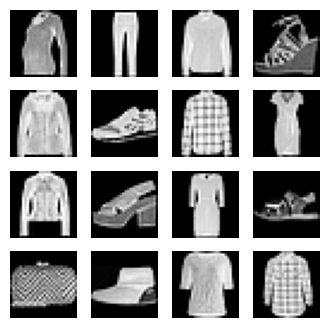

In [ ]:
# Display 16 random images from train dataset

indexes = np.random.randint(0, x_train.shape[0], size=16)
images = x_train[indexes]
labels = y_train[indexes]

plt.figure(figsize=(4,4))
for i in range(len(indexes)):
    plt.subplot(4, 4, i + 1)
    image = images[i]
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()
plt.savefig("FMNIST-samples.png")
plt.close('all')

classes = [T-shirt/top, Trouser, Pullover, Dress, Coat,Sandal, Shirt, Sneaker, Bag, Ankle boot]

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
# image dimensions (assumed square)
image_size = x_train.shape[1]
input_size = image_size * image_size
input_size

784

In [ ]:
# resize and normalize
x_train = np.reshape(x_train, [-1, input_size])
x_train = x_train.astype('float32') / 255
x_test = np.reshape(x_test, [-1, input_size])
x_test = x_test.astype('float32') / 255

In [ ]:
x_train.shape

(60000, 784)

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(256, input_dim=(input_size)))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
learning_rate = 0.001
optimizer =tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 335,114 (1.28 MB)

 Trainable params: 335,114 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

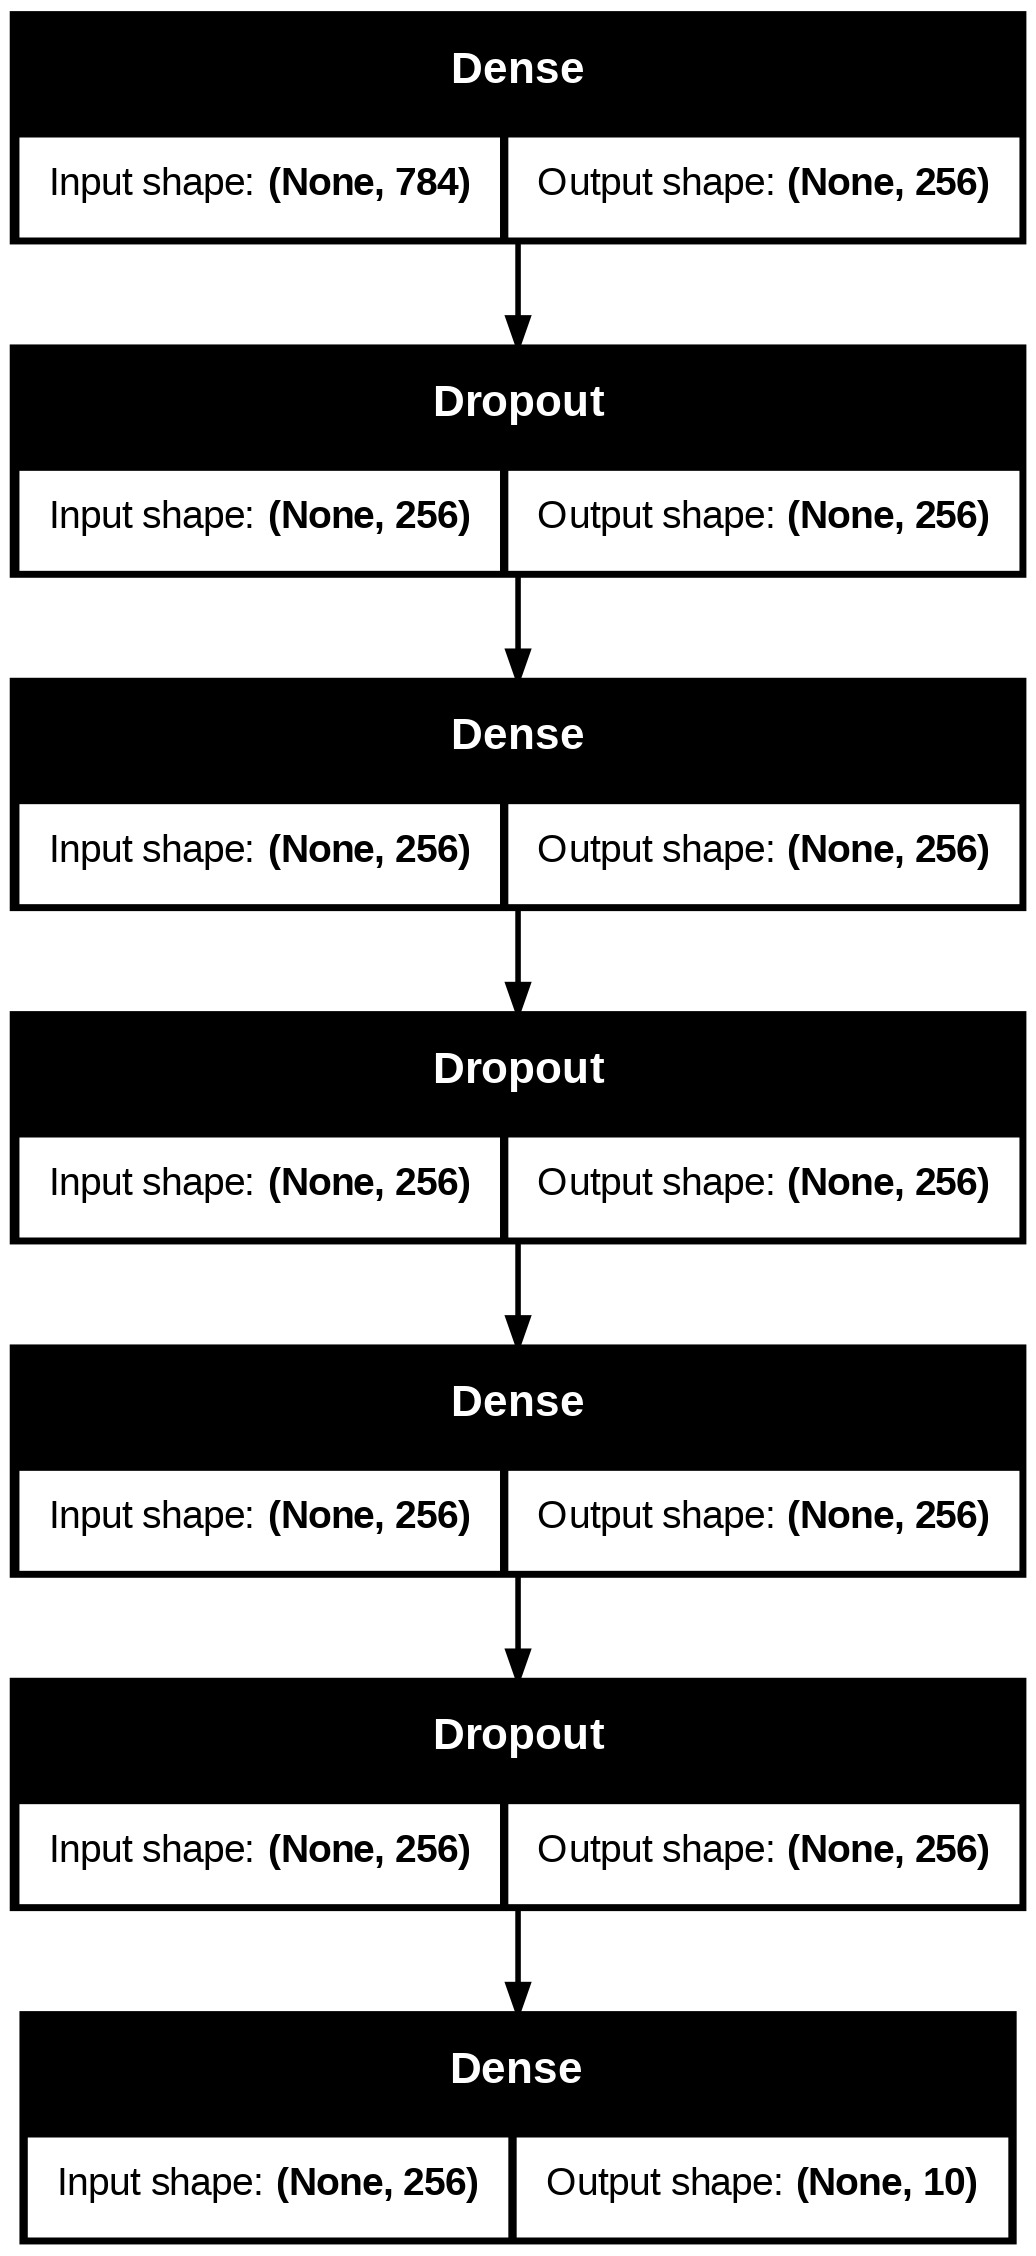

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='mlp-FashionMNIST.png', show_shapes=True)


In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3, batch_size=128)

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8764 - loss: 0.3355 - val_accuracy: 0.8783 - val_loss: 0.3444
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8786 - loss: 0.3367 - val_accuracy: 0.8744 - val_loss: 0.3417
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8780 - loss: 0.3337 - val_accuracy: 0.8844 - val_loss: 0.3359


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Test Loss: 0.3358727991580963
Test Accuracy: 0.8844000101089478


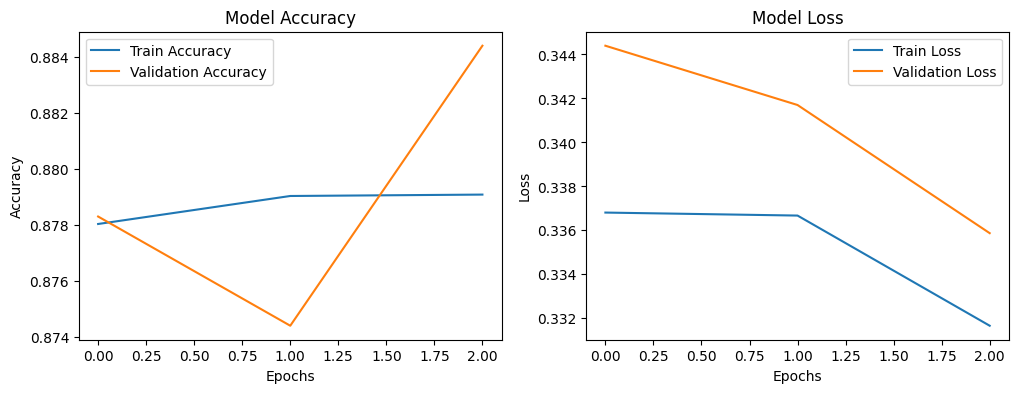

In [ ]:
plt.figure(figsize=(12, 4))
# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(x_test, batch_size=128)
predictions

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[9.9465075e-11, 5.3270190e-11, 1.7136532e-10, ..., 1.4922526e-02,
        7.4513352e-08, 9.8481679e-01],
       [8.6917125e-06, 1.6146580e-12, 9.8769706e-01, ..., 1.1094193e-20,
        2.1217379e-10, 3.9565093e-22],
       [4.9173199e-19, 9.9999994e-01, 1.6305069e-16, ..., 0.0000000e+00,
        1.3058280e-24, 1.4421163e-30],
       ...,
       [4.0603504e-06, 1.4048335e-09, 2.2095338e-07, ..., 4.4909797e-15,
        9.9985456e-01, 2.0475867e-17],
       [1.6816144e-11, 9.9999982e-01, 1.4705975e-09, ..., 5.8396474e-24,
        1.5467009e-12, 2.7073711e-17],
       [1.1106410e-14, 2.0033419e-19, 5.4959626e-12, ..., 3.2065273e-05,
        1.8778661e-09, 1.8553131e-08]], dtype=float32)

In [ ]:
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
predictions = model.predict(x_test, batch_size=128)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)
true_classes

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([9, 2, 1, ..., 8, 1, 5])

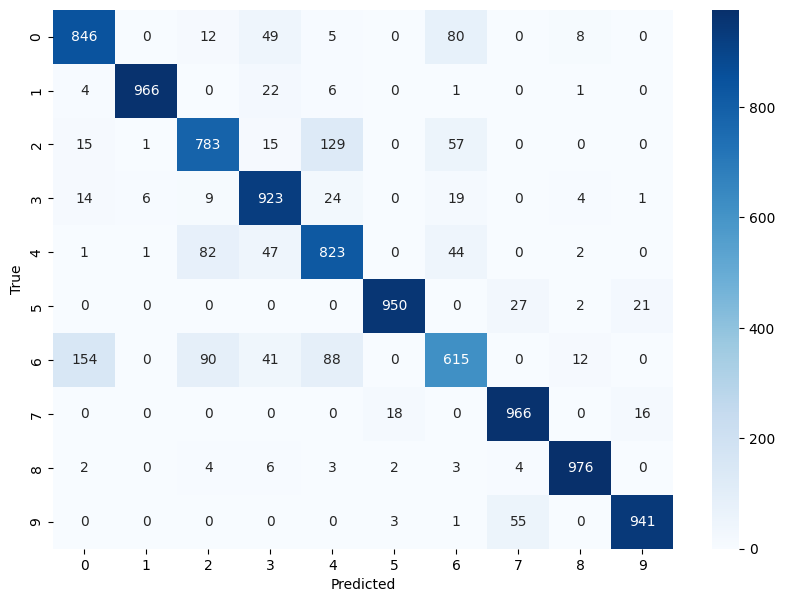

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
print(classification_report(y_test_classes, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.82      0.85      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.78      0.79      1000
           3       0.84      0.92      0.88      1000
           4       0.76      0.82      0.79      1000
           5       0.98      0.95      0.96      1000
           6       0.75      0.61      0.68      1000
           7       0.92      0.97      0.94      1000
           8       0.97      0.98      0.97      1000
           9       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



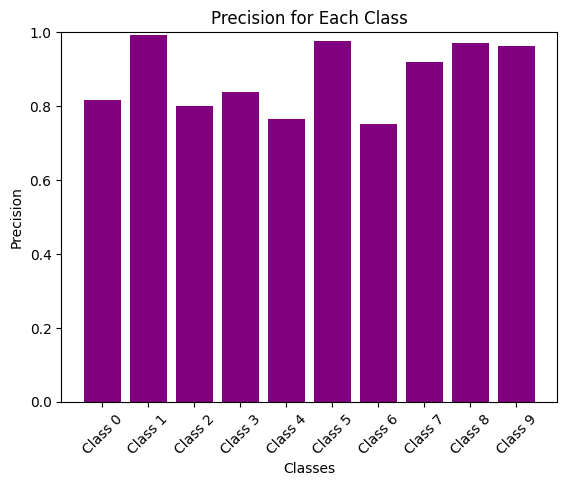

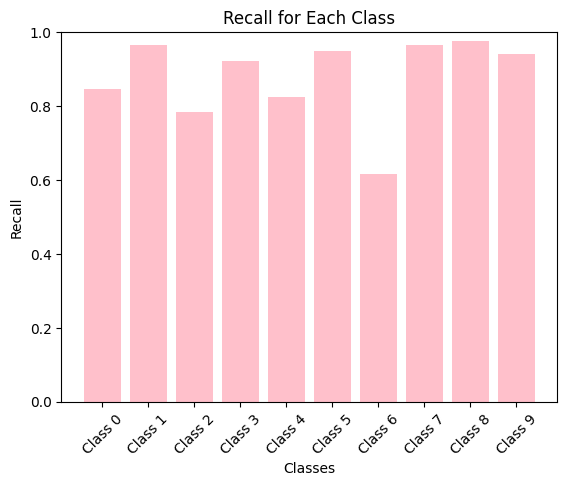

In [ ]:
# plot precision and recall
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test_classes, y_pred_classes, output_dict=True)

precision = [report[str(i)]['precision'] for i in range(10)]
recall = [report[str(i)]['recall'] for i in range(10)]
classes = [f"Class {i}" for i in range(10)]

plt.bar(classes, precision, color='purple')
plt.title('Precision for Each Class')
plt.xlabel('Classes')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

plt.bar(classes, recall, color='pink')
plt.title('Recall for Each Class')
plt.xlabel('Classes')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()


Prediction

In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Define Fashion MNIST classes
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def predict_image(model, image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Load and preprocess the image
    image = load_img(image_path, target_size=(28, 28), color_mode='grayscale')
    image_array = img_to_array(image)
    image_array = image_array / 255.0
    image_array = image_array.reshape(1, -1)

    # Predict the class
    predictions = model.predict(image_array)
    predicted_class = np.argmax(predictions, axis=1)[0]

    return classes[predicted_class]

# Predict on an image
image_path = '/content/bag1.jpg'
try:
    predicted_class = predict_image(model, image_path)
    print(f"Predicted class: {predicted_class}")
except Exception as e:
    print(e)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class: Bag
